# Media Authenticity Detection - ResNet50 (Transfer Learning)

**Model:** ResNet50 â€” classic deep residual network, pre-trained on ImageNet.

**Why ResNet50?**
- Well-balanced: faster than Xception, more accurate than simple CNNs
- 25M parameters (vs Xception 23M â€” similar but ResNet50 is faster in practice)

**Optimizations for CPU:**
- Image Size: 128Ã—128 (default 224Ã—224 reduced)
- Batch Size: 16
- Phase 1 (5 epochs): Custom head only, base frozen
- Phase 2 (10 epochs): Top 30 layers unfrozen, fine-tuned at low LR
- Auto-resume from checkpoint

In [1]:
import os, gc, re, glob, json, pickle
import tensorflow as tf
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import ResNet50
import matplotlib.pyplot as plt
import multiprocessing

NUM_CORES = multiprocessing.cpu_count()
tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)
print(f"TF: {tf.__version__} | Cores: {NUM_CORES}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
else:
    tf.config.set_visible_devices([], 'GPU')
    print("No GPU. CPU optimizations active.")

BASE_DIR        = os.path.join("..", "data", "processed", "images")
MODEL_SAVE_PATH = os.path.join("..", "models", "resnet50_model.keras")
MODEL_PKL_PATH  = os.path.join("..", "models", "resnet50_model.pkl")
CHECKPOINT_DIR  = os.path.join("..", "models", "checkpoints_resnet50")
STATE_FILE      = os.path.join(CHECKPOINT_DIR, "training_state.json")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

IMAGE_SIZE  = (128, 128)
BATCH_SIZE  = 16     # Good balance for ResNet50 on CPU
EPOCHS_HEAD = 5
EPOCHS_FINE = 10

print(f"Image: {IMAGE_SIZE}, Batch: {BATCH_SIZE}, Steps/epoch: {70000//BATCH_SIZE}")

TF: 2.21.0 | Cores: 12
No GPU. CPU optimizations active.
Image: (128, 128), Batch: 16, Steps/epoch: 4375


In [2]:
def find_latest_checkpoint(phase):
    files = glob.glob(os.path.join(CHECKPOINT_DIR, f"resnet50_{phase}_epoch_*.keras"))
    if not files: return None, 0
    def ep(f): m = re.search(r'epoch_(\d+)', f); return int(m.group(1)) if m else 0
    files.sort(key=ep)
    return files[-1], ep(files[-1])

def load_training_state():
    if os.path.exists(STATE_FILE):
        with open(STATE_FILE) as f: s = json.load(f)
        print(f"[State] {s}"); return s
    print("[State] Fresh start."); return {"phase": "p1", "last_completed_epoch": 0}

def save_training_state(phase, epoch, val_loss=None):
    s = {"phase": phase, "last_completed_epoch": epoch}
    if val_loss: s["best_val_loss"] = round(float(val_loss), 6)
    with open(STATE_FILE, 'w') as f: json.dump(s, f, indent=2)

class StateLogger(tf.keras.callbacks.Callback):
    def __init__(self, phase, initial_epoch=0):
        super().__init__(); self.phase = phase; self.initial_epoch = initial_epoch
    def on_epoch_end(self, epoch, logs=None):
        abs_ep = self.initial_epoch + epoch + 1
        save_training_state(self.phase, abs_ep, logs.get('val_loss') if logs else None)
        print(f"  [StateLogger] phase={self.phase}, epoch={abs_ep}")

print("Helpers loaded.")

Helpers loaded.


In [3]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR,'train'), image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR,'val'), image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR,'test'), image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

class_names = train_ds.class_names
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

gc.collect()
print(f"Classes: {class_names}")

Found 70000 files belonging to 2 classes.
Found 15000 files belonging to 2 classes.
Found 15000 files belonging to 2 classes.
Classes: ['fake', 'real']


In [4]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(128, 128, 3)
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=(128, 128, 3))
# ResNet50 expects pixels in [-1, 1] (same preprocessing as EfficientNet)
x       = tf.keras.applications.resnet50.preprocess_input(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='binary_crossentropy', metrics=['accuracy'])

print(f"Base trainable: {base_model.trainable}")
print(f"Total params: {model.count_params():,}")

Base trainable: False
Total params: 24,112,513


## Phase 1 â€” Head Training (Resume-Aware)

In [5]:
state = load_training_state()
p1_checkpoint, _ = find_latest_checkpoint("p1")
p1_initial_epoch = state["last_completed_epoch"] if state["phase"] == "p1" else EPOCHS_HEAD

history_p1 = None
if p1_initial_epoch >= EPOCHS_HEAD:
    print("Phase 1 complete. Loading best weights.")
    if p1_checkpoint: model.load_weights(p1_checkpoint)
else:
    if p1_checkpoint and p1_initial_epoch > 0:
        model.load_weights(p1_checkpoint)
        print(f"Resuming Phase 1 from epoch {p1_initial_epoch}")
    else:
        print("Starting Phase 1 from scratch.")

    print(f"=== Phase 1: Head only | {p1_initial_epoch+1} â†’ {EPOCHS_HEAD} ===")
    history_p1 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=EPOCHS_HEAD, initial_epoch=p1_initial_epoch,
        callbacks=[
            callbacks.ModelCheckpoint(
                os.path.join(CHECKPOINT_DIR, "resnet50_p1_epoch_{epoch:02d}.keras"),
                save_best_only=True, monitor='val_loss', verbose=1),
            callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            StateLogger(phase="p1", initial_epoch=p1_initial_epoch)
        ]
    )
    save_training_state("p2", 0)
    gc.collect()
    print("Phase 1 complete.")

[State] {'phase': 'p2', 'last_completed_epoch': 4, 'best_val_loss': 0.098165}
Phase 1 complete. Loading best weights.


D:\Media Validate App\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Phase 2 â€” Fine-Tune Top 30 Layers (Resume-Aware)

In [6]:
# Unfreeze top 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Unfrozen layers: {trainable_count}/{len(base_model.layers)}")

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='binary_crossentropy', metrics=['accuracy'])

state = load_training_state()
p2_checkpoint, p2_ckpt_epoch = find_latest_checkpoint("p2")
p2_initial_epoch = state["last_completed_epoch"] if state["phase"] == "p2" else 0

if p2_checkpoint and p2_initial_epoch > 0:
    model.load_weights(p2_checkpoint)
    print(f"Resuming Phase 2 from epoch {p2_initial_epoch}")
elif p2_checkpoint and p2_ckpt_epoch > 0:
    model.load_weights(p2_checkpoint); p2_initial_epoch = p2_ckpt_epoch
    print(f"Resuming from checkpoint epoch {p2_initial_epoch}")
else:
    print("Starting Phase 2 from scratch.")

print(f"=== Phase 2: Fine-tune | {p2_initial_epoch+1} â†’ {EPOCHS_FINE} ===")
history_p2 = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS_FINE, initial_epoch=p2_initial_epoch,
    callbacks=[
        callbacks.ModelCheckpoint(
            os.path.join(CHECKPOINT_DIR, "resnet50_p2_epoch_{epoch:02d}.keras"),
            save_best_only=True, monitor='val_loss', verbose=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
        StateLogger(phase="p2", initial_epoch=p2_initial_epoch)
    ]
)
gc.collect()
print("Phase 2 complete.")

Unfrozen layers: 30/175
[State] {'phase': 'p2', 'last_completed_epoch': 4, 'best_val_loss': 0.098165}
Resuming Phase 2 from epoch 4
=== Phase 2: Fine-tune | 5 â†’ 10 ===
Epoch 5/10


D:\Media Validate App\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


4375/4375 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.9841 - loss: 0.0443
Epoch 5: val_loss improved from None to 0.09433, saving model to ..\models\checkpoints_resnet50\resnet50_p2_epoch_05.keras

Epoch 5: finished saving model to ..\models\checkpoints_resnet50\resnet50_p2_epoch_05.keras
  [StateLogger] phase=p2, epoch=9
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 3782s 861ms/step - accuracy: 0.9837 - loss: 0.0451 - val_accuracy: 0.9690 - val_loss: 0.0943 - learning_rate: 1.0000e-05
Epoch 6/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.9915 - loss: 0.0257
Epoch 6: val_loss did not improve from 0.09433
  [StateLogger] phase=p2, epoch=10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 3689s 840ms/step - accuracy: 0.9911 - loss: 0.0258 - val_accuracy: 0.9695 - val_loss: 0.0997 - learning_rate: 1.0000e-05
Epoch 7/10
4375/4375 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.9942 - loss: 0.0168
Epoch 7: val_loss did not improve from 0.09433

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.99

In [7]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nTest Accuracy: {test_acc:.4f} | Test Loss: {test_loss:.4f}")
model.save(MODEL_SAVE_PATH)
print(f"Saved to {MODEL_SAVE_PATH}")
try:
    with open(MODEL_PKL_PATH, 'wb') as f: pickle.dump(model, f)
    print(f"Pickle saved to {MODEL_PKL_PATH}")
except Exception as e:
    print(f"Pickle failed: {e}")

938/938 ━━━━━━━━━━━━━━━━━━━━ 283s 302ms/step - accuracy: 0.9681 - loss: 0.0949

Test Accuracy: 0.9681 | Test Loss: 0.0949
Saved to ..\models\resnet50_model.keras
Pickle saved to ..\models\resnet50_model.pkl


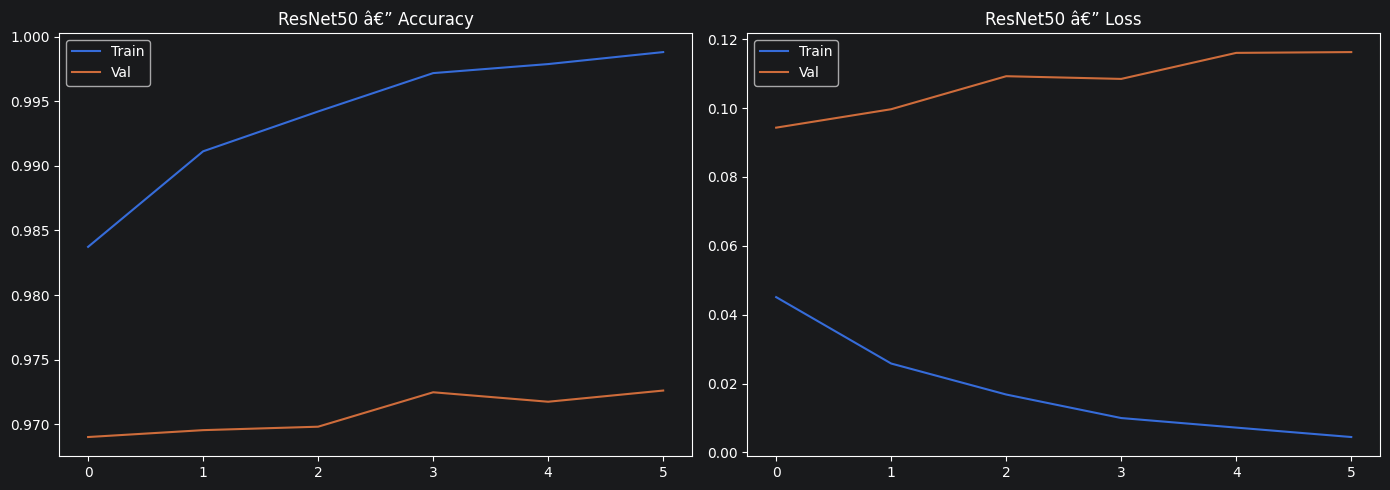

Plot saved.


In [8]:
p1_acc  = history_p1.history.get('accuracy', [])     if history_p1 else []
p1_loss = history_p1.history.get('loss', [])         if history_p1 else []
p1_va   = history_p1.history.get('val_accuracy', []) if history_p1 else []
p1_vl   = history_p1.history.get('val_loss', [])     if history_p1 else []

acc      = p1_acc  + history_p2.history.get('accuracy', [])
loss     = p1_loss + history_p2.history.get('loss', [])
val_acc  = p1_va   + history_p2.history.get('val_accuracy', [])
val_loss = p1_vl   + history_p2.history.get('val_loss', [])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(acc, label='Train'); ax1.plot(val_acc, label='Val')
if p1_acc: ax1.axvline(x=len(p1_acc)-1, color='r', linestyle='--', label='Fine-tune start')
ax1.set_title('ResNet50 â€” Accuracy'); ax1.legend()

ax2.plot(loss, label='Train'); ax2.plot(val_loss, label='Val')
if p1_loss: ax2.axvline(x=len(p1_loss)-1, color='r', linestyle='--', label='Fine-tune start')
ax2.set_title('ResNet50 â€” Loss'); ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join("..", "models", "resnet50_training_history.png"))
plt.show(); print("Plot saved.")